## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [75]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=;AccountKey=;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [76]:
#Anya

#Task 1.2
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=;AccountKey=;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to a pandas DataFrame
df_house_price = pd.read_csv(StringIO(csv_content))


#Task 1.3
# Display the first few rows
display(df_house_price.head(5))


In [77]:
# Task 1.4 Missing values

#    Check for missing values
missing_values = df_house_price.isnull()

nulls = df_house_price[missing_values.any(axis=1)]

#   Display the rows with null values
display(nulls)

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

Task 2.5.  Write 1–2 sentences for each visualisation explaining the insights you gained from the chart.

In [78]:
#Task 2.1
print(df_house_price.describe())


       Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Garage_Size  \
count   500.000000    500.000000     500.000000  500.000000   500.000000   
mean    174.640428      2.958000       1.976000    1.964000    30.174000   
std      74.672102      1.440968       0.820225    0.802491    11.582575   
min      51.265396      1.000000       1.000000    1.000000    10.000000   
25%     110.319923      2.000000       1.000000    1.000000    20.000000   
50%     178.290937      3.000000       2.000000    2.000000    30.000000   
75%     239.031220      4.000000       3.000000    3.000000    41.000000   
max     298.241199      5.000000       3.000000    3.000000    49.000000   

       Location_Score  Distance_to_Center          Price  
count      500.000000          500.000000     500.000000  
mean         5.164410           10.469641  582209.629531  
std          2.853489            5.588197  122273.390347  
min          0.004428            0.062818  276892.470100  
25%          2.76065

- The average house is approximately a 2 story, 3 bedroom two bathroom place with a 30 square foot garage (feet is assumed based on house) and a 175 square foot floor plan.
- The statistics above show that the average house price based on the dataset is approximately $580,000 with values ranging from aproximately $277,000 to $960,000. 
- Prices in the upper quartile vary a lot more significantly than the lower quartile.


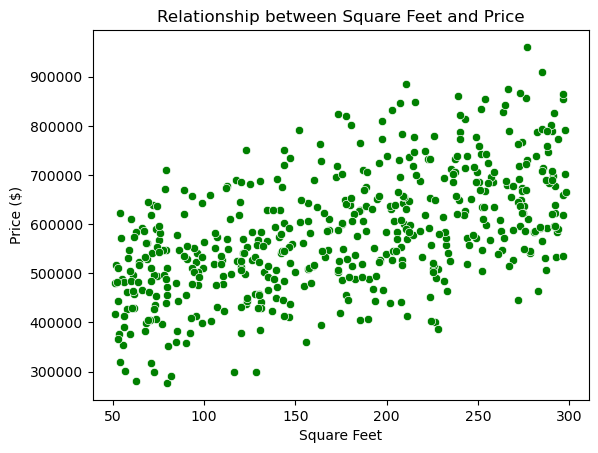

In [79]:
#Task 2.2
##Import Seaborn matplotlib
!pip install seaborn matplotlib

import seaborn as sns
import matplotlib.pyplot as plt

#Create scatterplot
sns.scatterplot(data=df_house_price, x='Square_Feet', y='Price', color='green')
plt.title('Relationship between Square Feet and Price')
plt.xlabel('Square Feet')
plt.ylabel('Price ($)')
plt.show()

- Scatterplot shows there is a correlation between square feet and price, but this is not necessarily a determining factor in estimating price as there are still plenty of houses with large footprints that are selling for under $600,000.
However, there are very few houses under 150 square feet selling for more than $700,000.

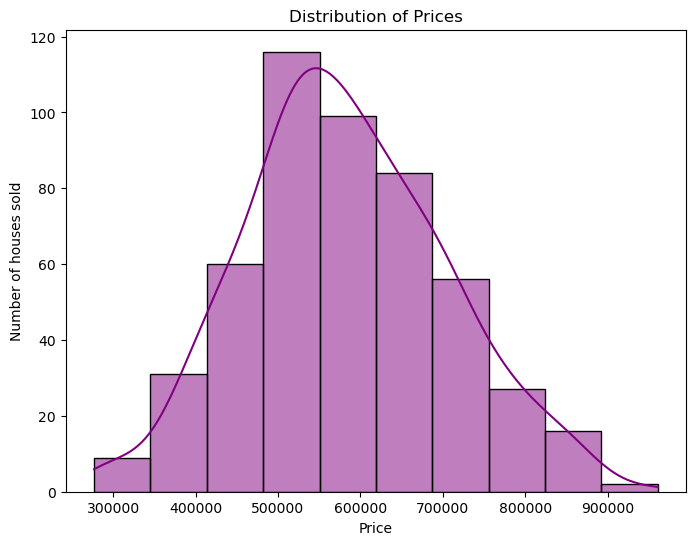

In [80]:
#Task 2.3 - Histogram for price

plt.figure(figsize=(8, 6))
sns.histplot(df_house_price['Price'], bins=10, color='purple', kde=True)
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Number of houses sold')
plt.show()

As identified in the earlier visualisations, prices in the upper quartile vary a lot more significantly than the lower quartile.
Based on the histogram above, the largest number of houses to be sold appear to be in the $480,000 - $550,000 price range with more listings sitting below the average of $580,000 than above. 


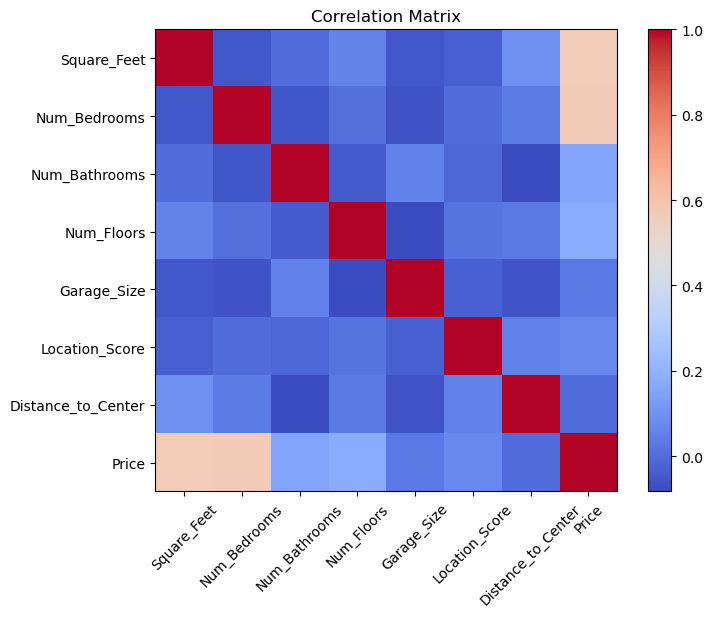

In [81]:
#Task 2.4 - correlation matrix

correlation_matrix = df_house_price.corr()

# Heatmap of correlations using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)

# Title and labels
plt.title('Correlation Matrix')
plt.show()


As identified in the scatterplot there is correlation between the square footage of the house and the price the house sells for. This correlation matrix also shows that the strongest correlation is actually between number of bedrooms and price. However, these correlations are not particularly strong. 
Interestingly, the correlation between location score, distance to center or garage size and the price a house commands is very low. Also, the correlation between number of bedrooms and square footage is low which is unexpected. 

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

Task 3.6. Write 1–2 sentences explaining the insights from the visualisation.

In [82]:
##jessica 
#task 3.1 and 3.2
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np
#independent variable = x, dependent variable = y 
X = df_house_price[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Garage_Size', 'Location_Score', 'Distance_to_Center']]
y = df_house_price['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


display(X_train)
display(y_train)
display(X_test)
display(y_test)

I used this setup because its the standard way to prepare a model properly. I picked the main house features as inputs, then split the data into training and testing sets so I could check whether the model actually learns something real instead of just memorising the data. it makes the results more trustworthy


In [83]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
#using .ravel to flatten the variables as it was coming up with vaule error 
actual_prices = np.ravel(y_test)
predicted_prices = np.ravel(y_pred)

results_multi = pd.DataFrame({
    'Actual Sale': actual_prices, 
    'Predicted Sale': predicted_prices
})

display(results_multi)


🏃 View run serene_cumin_2kvvwt0j at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/c10da962-5b93-42cd-8b95-8ad29fc7223c/#/experiments/0b23e1d0-6cb9-498b-b95f-8a8bcedc4252/runs/ae957e1f-e408-48df-9e08-a2eaaa8622d7
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/c10da962-5b93-42cd-8b95-8ad29fc7223c/#/experiments/0b23e1d0-6cb9-498b-b95f-8a8bcedc4252


I used this code to train the linear regression model and compare its predictions to the real prices. 'ravel()' was  just needed to flatten the outputs so I could line them up properly in a results table. Assumingly the reason the initial code did not work because of the double brackets inside the first part of step 3 but i decided to keep it in, as it did not impact the results



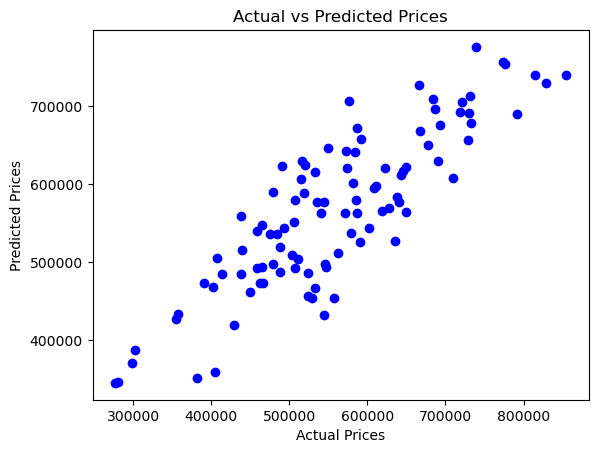

In [84]:
#scatterplot

plt.scatter(actual_prices, predicted_prices, color='blue')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

Scatterplot to show our trained data is working/predicting as it should
and is in the linear. 

In [85]:
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Multiple Linear Regression RMSE: {rmse_multi}")

Multiple Linear Regression RMSE: 63952.37599755184


Then we end with the RMSE calculation, which seems to be accurate to the data given to us. However when it is handling messy data, we miss out on any complex insights that we can pull from the model. it assumes that the data will be in a linear direction.


## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [86]:
#Task 4.1 - RANDOM FOREST
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the Random Forest model on the training data
model_rf.fit(X_train, y_train)


# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)



🏃 View run gentle_fly_jsymlc5s at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/c10da962-5b93-42cd-8b95-8ad29fc7223c/#/experiments/0b23e1d0-6cb9-498b-b95f-8a8bcedc4252/runs/db00c247-91fa-4d5d-92a0-4cacab4d6bd7
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/c10da962-5b93-42cd-8b95-8ad29fc7223c/#/experiments/0b23e1d0-6cb9-498b-b95f-8a8bcedc4252


I tried estimators of 100, 200, and 500 and while the 500 was the most accurate it was not significantly different to the 100 and had more impact on the speed of performance of model. As such, I used the 100 value.

     Actual Price  Predicted Price (Random Forest)
361   591058.7089                    503384.607235
73    667693.0003                    655165.699108
374   532377.5802                    563554.164957
155   478489.2990                    483272.593705
104   730197.4806                    754956.762521


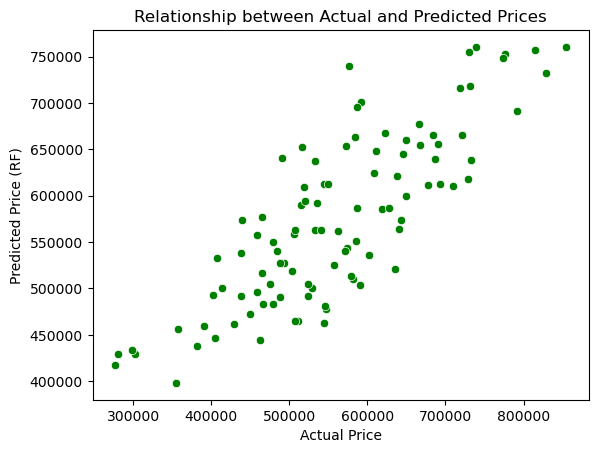

In [87]:
#Task 4.2

# Create a table with Actual vs Predicted Prices for Random Forest
results_df_rf = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (Random Forest)': predicted_prices_rf
})

# Display the table
print(results_df_rf.head())


#Create scatterplot
sns.scatterplot(data=results_df_rf, x='Actual Price', y='Predicted Price (Random Forest)', color='green')
plt.title('Relationship between Actual and Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price (RF)')
plt.show()


Scatterplot shows that values for the actual and predicted prices are not necessarily tightly coupled but generally follow the same trend. 

In [88]:
#Task 4.3
# Calculate RMSE for Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"Root Mean Squared Error (RMSE) for Random Forest: {rmse_rf}")

# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df.head())  # Shows the first few rows of the table

# Compare the RMSE of both models
print(f"RMSE for MLR: {rmse_multi}")
print(f"RMSE for Random Forest: {rmse_rf}")

# Provide insights
if rmse_multi < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model performs better based on RMSE.")


Root Mean Squared Error (RMSE) for Random Forest: 71733.35944826744
     Actual Price  Predicted Price (MLR)  Predicted Price (Random Forest)
361   591058.7089          525669.926934                    500189.353421
73    667693.0003          668141.051861                    655943.350060
374   532377.5802          467168.904743                    563209.779665
155   478489.2990          498375.548472                    487954.681220
104   730197.4806          691359.973840                    768464.412341
RMSE for MLR: 63952.37599755184
RMSE for Random Forest: 71733.35944826744
The Multiple Linear Regression model performs better based on RMSE.


As you can see in the values above - the Random Forest Model has some instances where it is close to actual prices, but also some where it differs significantly. While this is also true for the MLR model, it has less significant differences than the Random Forest model and performs better based on RMSE.

## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

##### Task 5.1
###### Insights and recommendations from EDA
- Number of bedrooms is the best predictor of price based on correlation as the higher number of bedrooms the higher the likely price but even this is not a particularly strong correlation. 
- This is followed by the square footage of the home. 
- Interestingly, the correlation between location score, distance to center or garage size and the price a house commands is very low.
- The average house is approximately a 2 story, 3 bedroom two bathroom place with a 30 square foot garage (feet is assumed based on house) and a 175 square foot floor plan. The average cost is $580,000.
- Prices in the upper quartile vary a lot more significantly than the lower quartile.

##### Insights from predictive models
The MLR model with an RMSE of $63,952 outperformed the Random Forest model with an RMSE of $71,733, indicating more accurate predictions. The lower RMSE corresponds to an average prediction error of approximately 11.0% of the average house price, compared with 12.4% for the second model. The MLR model also performed better than the Random Forest model based on the visualisations performed above.The MLR values are closer to the actual prices provided and the scatterplot shows a tighter relationship between the predicted values of the MLR model and the actual prices than that of the Random forest.

the Linear regression tries to force everything into one simple relationship, so it misses a lot of the real world variation. The forests many decision trees just do a better job of capturing how house prices actually behave.


##### Improvements
Having a larger dataset would increase the accuracy of both models, but would have an impact on the speed of the predictions. Given that the runtime currently is approximately 5 seconds but accuracy is not very strong, additional data would be of sgnificant value to the model even at the price of the runtime speed. 

The dataset also doesn't include any view on seasonality which could have an impact on pricesand enable better predictions going forward - so potentially this information should be added if possible to enable more accurate predictions in the future.



Well done. Good effort. Keep it up